# Классификация веб-контента: От базовых методов к Deep Learning

Идея: провести сравнительный анализ разных подходов в задаче детекции "запрещенных" сайтов.

Описание задачи: задача состоит в бинарной классификации веб-страниц по их URL и заголовкам.
Нам нужно отделить безопасный контент от категории "для взрослых".

## Data

Данные для проекта взяты из закрытого соревнования. Исходные файлы (train.csv, test.csv) не включены в репозиторий в целях соблюдения конфиденциальности. Вы можете найти их по ссылке: [Porn detection dataset](https://www.kaggle.com/datasets/dulinaira/porn-detection-dataset).

Распакуйте их в папку `/data` в корне проекта.

## EDA (exploratory data analysis)

Посмотрим на изначальный датасет:

In [1]:
import pandas as pd

training_ds = "data/train.csv"

train_df = pd.read_csv(training_ds)
train_df.head()

,ID,url,title,label
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0


In [2]:
train_df.shape

(135309, 4)

In [3]:
train_df['label'].value_counts()

label
0    118594
1     16715
Name: count, dtype: int64

Особенности данных: мы имеем дело с сильно несбалансированной выборкой и короткими текстовыми фрагментами (заголовки, домены).

In [4]:
# Тестовая выборка
test_df = pd.read_csv("data/test.csv")
truth_df = pd.read_csv("data/truth2.csv")
test_df['true_label'] = truth_df['label']

In [5]:
test_df.head()

,ID,url,title,true_label
0,135309,www.kommersant.ru,Шестой кассационный суд в Самаре начнет работу...,0
1,135310,urexpert.online,"Что такое индексация алиментов, кем и в каких ...",0
2,135311,imperimeha.ru,Женщинам | Империя Меха - Part 12,0
3,135312,national-porn.com,"Небритые, волосатые киски: Порно всех стран и ...",1
4,135313,2gis.ru,67,0


In [6]:
def accuracy_sc(*, tp, tn, fp, fn):
    return (tp + tn) / (tp + tn + fp + fn)
def precision_sc(*, tp, fp):
    return tp / (tp + fp + 1e-9)
def recall_sc(*, tp, fn):
    return tp / (tp + fn + 1e-9)

def f1_sc(*, precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-9)

## TF-IDF

### Препроцессинг

К TF-IDF, который подсчитывает количество слов, применим леммитазацию, чтобы разные формы слова считались одним целым

In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import pymorphy3

# Загружаем стоп-слова (предлоги, союзы и т.д., которые не несут смысла)
nltk.download('stopwords')
stop_words = set(stopwords.words('russian')).union(set(stopwords.words('english')))

morph = pymorphy3.MorphAnalyzer()

# Создаем словарь(кэш), чтобы не лемматизировать одно и то же слово дважды
lemma_cache = {}

def clean_and_lemmatize(text):
    text = str(text).lower()

    text = re.sub(r'[^a-zа-яё]', ' ', text)

    words = text.split()
    lemmas = []

    for w in words:
        if w in stop_words:
            continue # Пропускаем мусорные слова

        if w not in lemma_cache:
            # Лемматизируем только если слова нет в кэше
            lemma_cache[w] = morph.parse(w)[0].normal_form

        lemmas.append(lemma_cache[w])

    return " ".join(lemmas)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\troti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Очищаем обучающую выборку

In [8]:
train_url_clean = train_df['url'].apply(clean_and_lemmatize)
train_title_clean = train_df['title'].apply(clean_and_lemmatize)

Очищаем тестовую выборку

In [9]:
test_url_clean = test_df['url'].apply(clean_and_lemmatize)
test_title_clean = test_df['title'].apply(clean_and_lemmatize)

Создаем два отдельных векторизатора для `url` и для `title`

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_url = TfidfVectorizer(max_features=50000)
vectorizer_title = TfidfVectorizer(max_features=100000, ngram_range=(1, 2))

Векторизируем url

In [11]:
X_train_url = vectorizer_url.fit_transform(train_url_clean)
X_test_url  = vectorizer_url.transform(test_url_clean)

Векторизируем title

In [12]:
X_train_title = vectorizer_title.fit_transform(train_title_clean)
X_test_title  = vectorizer_title.transform(test_title_clean)

Интересно посмотреть на самые редкие слова

In [13]:
idf_df = pd.DataFrame({'word': vectorizer_title.get_feature_names_out(),
                       'idf_weight': vectorizer_title.idf_})

print("Самые редкие слова:")
print(idf_df.sort_values(by='idf_weight', ascending=False).head(10))

print("\nСамые частотные слова (низкий IDF):")
print(idf_df.sort_values(by='idf_weight', ascending=True).head(10))


Самые редкие слова:
                   word  idf_weight
33471     вязание палец   12.122177
5                   aai   12.122177
6           aai marathi   12.122177
52999    корпорация sun   12.122177
99986      ёжик плавать   12.122177
33481          вязанний   12.122177
33485  вязаный кардиган   12.122177
64054     назад android   12.122177
99980  ящик центральный   12.122177
53004        корпус hdd   12.122177

Самые частотные слова (низкий IDF):
            word  idf_weight
20513         ru    3.271086
67350     онлайн    3.444822
28469  бесплатно    3.810901
85389    скачать    3.885359
97208       цена    3.983028
15930       mail    3.999064
15931    mail ru    4.014306
54856     купить    4.039620
70982      поиск    4.053460
86628   смотреть    4.092092


Склеиваем (hstack) матрицы признаков по горизонтали

In [14]:
from scipy.sparse import hstack

X_train_combined = hstack([X_train_url, X_train_title])
X_test_combined  = hstack([X_test_url, X_test_title])

### Обучение

In [15]:
all_feature_names = list(vectorizer_url.get_feature_names_out()) + list(vectorizer_title.get_feature_names_out())

row = X_train_combined[0]

word_values = [
    (all_feature_names[i], row.data[idx])
    for idx, i in enumerate(row.indices)
]

word_values.sort(key=lambda x: x[1], reverse=True)

for word, score in word_values:
    print(f"Слово: {word:20} | Вес TF-IDF: {score:.4f}")

Слово: md                   | Вес TF-IDF: 0.7227
Слово: kp                   | Вес TF-IDF: 0.6912
Слово: который сделать      | Вес TF-IDF: 0.3317
Слово: донор                | Вес TF-IDF: 0.3270
Слово: избегать             | Вес TF-IDF: 0.3230
Слово: нахождение           | Вес TF-IDF: 0.3084
Слово: долгий               | Вес TF-IDF: 0.2954
Слово: министр              | Вес TF-IDF: 0.2761
Слово: экс                  | Вес TF-IDF: 0.2717
Слово: молдова              | Вес TF-IDF: 0.2650
Слово: цель                 | Вес TF-IDF: 0.2534
Слово: экономика            | Вес TF-IDF: 0.2334
Слово: республика           | Вес TF-IDF: 0.2121
Слово: сделать              | Вес TF-IDF: 0.2087
Слово: который              | Вес TF-IDF: 0.1931
Слово: глава                | Вес TF-IDF: 0.1774


Что мы имеем? Огромную матрицу one-hot encoded, где присутствие слова в тексте кодируется его TF-IDF весом.

Обучать будем на такой матрице базовую модель - логистическую регрессию. Причины:
* В отличие от FastText или BERT, в логистической регрессии мы можем четко увидеть веса каждого слова и понять, почему модель приняла то или иное решение.
* Интересно будет в конце сравнить классический алгоритм с FastText и BERT.

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [53]:
%%time

lr_model.fit(X_train_combined, train_df['label'])

CPU times: total: 1.44 s
Wall time: 1.5 s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Предсказание

In [17]:
y_pred_tf_idf = lr_model.predict(X_test_combined)
test_df['tfidf_label'] = y_pred_tf_idf

### Метрики

In [18]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_tf_idf).ravel()
accuracy = accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn)
precision = precision_sc(tp=tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
f1 = f1_sc(precision=precision, recall=recall)
# 2. Создаем словарь с результатами
tfidf_results = {
    'Model': 'TF-IDF + LogReg',
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1, 4)
}

results_table = pd.DataFrame([tfidf_results])
display(results_table)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + LogReg,0.9879,0.9321,0.973,0.9521


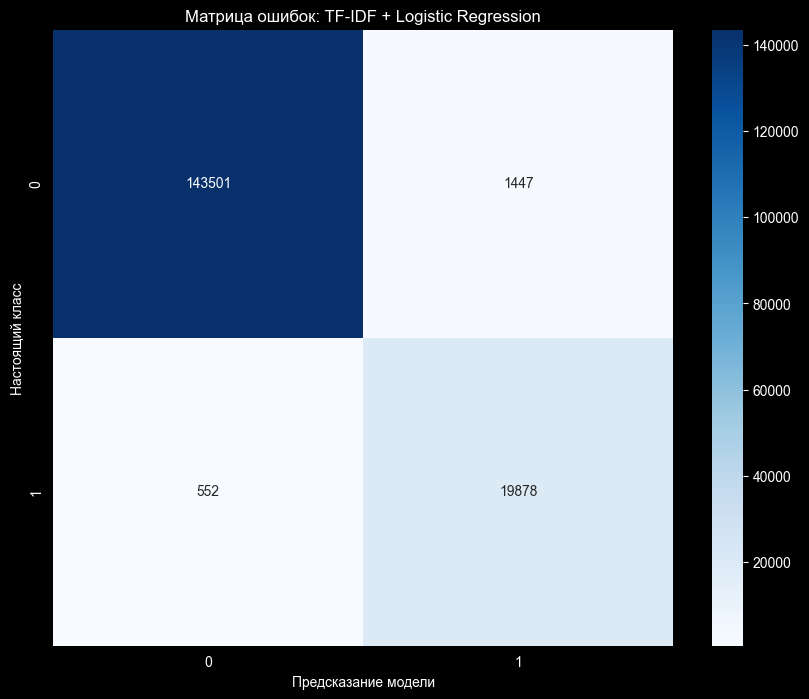

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['true_label'], y_pred_tf_idf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок: TF-IDF + Logistic Regression')
plt.ylabel('Настоящий класс')
plt.xlabel('Предсказание модели')
plt.show()

In [21]:
errors_df =test_df[test_df['tfidf_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

for idx, row in errors_df.sample(5, random_state=42).iterrows():
    # На вашем скриншоте я видел, что текст состоит из title + url
    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['tfidf_label']}")
    print("="*60)

Всего совершено ошибок: 1999 из 165378 примеров

Text: Карточки Домана.Фигуры | masik.tv
True: 0
Predicted: 1
Text: Еще приколы | korzik.net
True: 0
Predicted: 1
Text: беег.ком » XXX Сучки - порно видео онлайн | xxxsuchki.ru
True: 1
Predicted: 0
Text: Порвался презерватив порно онлайн | holzmin.ru
True: 1
Predicted: 0
Text: Летом женщины гуляют без трусиков | lezbiyanki.net
True: 0
Predicted: 1


**ВЫВОД**:

Ключевые особенности реализации:

- Использован раздельный подход к обработке признаков: колонки URL и Title обрабатывались независимыми векторизаторами, после чего объединялись в единую разреженную матрицу через hstack. Это позволило модели учитывать разную значимость слов в адресе сайта и в его заголовке.
- Для борьбы с дисбалансом классов (NSFW-контента значительно меньше) был применен параметр class_weight='balanced'.
- Включение n-грамм (размером от 1 до 2 слов) позволило модели улавливать устойчивые словосочетания, повысив тем самым точность на специфических тематиках.

Результаты:

-  F1-score (Macro) на тестовой выборке составил `0.9521`.
- Accuracy модели — `0.9879`.
- Количество ошибок: `1999`

Наблюдения и анализ ошибок:

- Модель показала отличные результаты в выявлении характерных слов-маркеров, благодаря их высокому весу в TF-IDF.
- При анализе ошибок (Error Analysis) было выявлено, что модель иногда ошибается на очень коротких заголовках, где TF-IDF веса недостаточно велики для уверенного решения.
- Также обнаружены случаи «шума» в исходной разметке данных, где модель верно классифицировала подозрительный контент, хотя в разметке он был помечен как безопасный.

## FastText

In [22]:
import fasttext

FastText - библиотека для обучения векторных представлений слов и классификации текста, созданная лабораторией AI Research (FAIR) Facebook.

Она разделяет слова на n-граммы, а векторное представление самого слова вычисляет как сумму ембеддингов этих n-грамм.

### Препроцессинг

In [23]:
# Объединяем URL и заголовок в один текст (фичи)
X = train_df['url'].fillna('') + ' ' + train_df['title'].fillna('')

# таргет
y = train_df['label']

Разрезаем длинные строки на слова (токены), а также применяем стемминг - удаление окончаний слова, чтобы разные формы одно и того же слова относились к одному понятию:

In [24]:
import re
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("russian")
def tokenizer(text):
    text = text.lower()

    parts = text.split(' ', 1) # url and title
    url_part = parts[0]
    title_part = parts[1] if len(parts) > 1 else ""

    # Убираем протоколы и www в начале
    url_part = re.sub(r'^(https?://)?(www\.)?', '', url_part)
    # Разбиваем домен на части по точкам
    domain_pieces = url_part.split('.')

    boring_tlds = {'ru', 'com', 'net', 'org', 'by', 'md', 'ua', 'online', 'spb', 'net'}
    url_tokens = [p for p in domain_pieces if p not in boring_tlds and len(p) >= 3]

    # В заголовке разрешаем слова от 3 символов
    title_tokens = re.findall(r'[а-яА-Яa-zA-Z]{3,}', title_part)

    final_tokens = [stemmer.stem(t) for t in (url_tokens + title_tokens)]

    return final_tokens

Делим `train.csv` на обучающую и валидационную выборки для оценки модели во время обучения

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

Для FastTest нужно привести метки к виду `__label__<n>`

In [26]:
# подготовим файлы с датасетами для фасттекста
train_df["label_ft"] = train_df["label"].apply(lambda x: "__label__" + str(x))
train_df.head()

,ID,url,title,label,label_ft
0,0,m.kp.md,"Экс-министр экономики Молдовы - главе МИДЭИ, ц...",0,__label__0
1,1,www.kp.by,Эта песня стала известна многим телезрителям б...,0,__label__0
2,2,fanserials.tv,Банши 4 сезон 2 серия Бремя красоты смотреть о...,0,__label__0
3,3,colorbox.spb.ru,Не Беси Меня Картинки,0,__label__0
4,4,tula-sport.ru,В Новомосковске сыграют следж-хоккеисты алекси...,0,__label__0


In [27]:
X_train_clean = X_train.apply(lambda x: ' '.join(tokenizer(str(x))))

In [28]:
X_train[:5], X_train_clean[:5]

(36898     karat.spb.ru Амиксидин: продажа, цена в Санкт-...
 69667                        samara.farfor.ru Ультрасет new
 111124    www.zr.ru Lada Vesta Cross: видеообзор с презе...
 35818     xn----htbdmodofzkc0c.xn--p1ai Фрезерный станок...
 123149    porno365.co Популярное порно по просмотрам - п...
 dtype: str,
 36898     karat амиксидин продаж цен санкт петербург мед...
 69667                           samara farfor ультрасет new
 111124    lada vesta cross видеообзор презентац серийн м...
 35818     xn----htbdmodofzkc0c xn--p1ai фрезерн станок м...
 123149    porno365 популярн порн просмотр порнух популяр...
 dtype: str)

In [29]:
X_valid_clean = X_valid.apply(lambda x: ' '.join(tokenizer(str(x))))

In [30]:
X_valid_clean[:5]

54589     kinotrast сериа качел белар все сер смотрет он...
41071     pc01 шкаф спальн гарнитур энрик руб грозн анал...
19161     forum zoneofgames swat close quarters battle р...
75429     librebook чита онлайн электрон книг промет ил ...
121091    meduniver как науч щедрост собствен мужчин оту...
dtype: str

In [31]:
train_ds = pd.concat([X_train_clean.apply(lambda x: re.sub('\t', '', x)),
                           y_train.apply(lambda x: '__label__' + str(x))], axis=1)

valid_ds = pd.concat([X_valid_clean.apply(lambda x: re.sub('\t', '', x)),
                          y_valid.apply(lambda x: '__label__' + str(x))], axis=1)

Чтобы улучшить метрики модели, мы будем насильно штрафовать её за ошибки ещё больше раз, для этого хардкорно продублируем данные с меткой label = 1.

In [32]:
minority_class = train_ds[train_ds.iloc[:, 1] == '__label__1']
print(minority_class[0])

oversampled_data = pd.concat([train_ds, minority_class, minority_class, minority_class, minority_class], axis=0)

# Перемешиваем данные
oversampled_data = oversampled_data.sample(frac=1, random_state=42).reset_index(drop=True)

123149    porno365 популярн порн просмотр порнух популяр...
131576         erkiss2 порва пизд красив блондинк порн виде
28367     daftsex watchingmymomgoblack nicole moore big ...
46206     lerporn брюнетк порн онлайн страниц брюнетк по...
40191     berufsbildungsbericht info nudist mother son p...
                                ...                        
56886     xnxxn pro russian category page free porn sex ...
65725     sex-za-dengi порн ебл груд красив деньг смотре...
123855                   oxporno популярн порн виде телефон
126324    sex-kadr гол ренат литвинов смотрет онлайн вид...
110268                pornophoto pro смотрет брит вагин фот
Name: 0, Length: 13375, dtype: str


In [33]:
print(f"Было строк: {len(train_ds)}")
print(f"Стало строк после дублирования: {len(oversampled_data)}")
print(f"Распределение классов: {train_ds['label'].value_counts(0)}")

Было строк: 108247
Стало строк после дублирования: 161747
Распределение классов: label
__label__0    94872
__label__1    13375
Name: count, dtype: int64


In [34]:
train_ds = oversampled_data

`train_ds` — это просто таблица (DataFrame).
Чтобы FastText начал учиться, эту таблицу нужно сохранить в текстовый файл без лишних кавычек и запятых.

In [35]:
import os
os.makedirs("fasttext", exist_ok=True)

train_ds.to_csv("fasttext/train_ds.txt", sep='\t', header=None, index=None)
valid_ds.to_csv("fasttext/valid_ds.txt", sep='\t', header=None, index=None)

In [36]:
with open("fasttext/train_ds.txt", "r", encoding="utf-8") as f:
    for _ in range(5): # Выведет первые 5 строк
        print(f.readline().strip())

liebelib yas xxx vidio first time porn tube videos	__label__1
xn----itbooccbfegeay русск инцест русск порн инцест виде страниц	__label__1
genderi tarihi yeri stanbul renim durumu	__label__0
perfectgirls anal porn perfect girls	__label__1
prom подвесн нсп цен грн куп николаев prom	__label__0


### Обучение

In [54]:
%%time
model = fasttext.train_supervised(
    input="fasttext/train_ds.txt",
    epoch=14,
    lr = 0.4,
    # minCount=5,  # отсеиваем редкие токены
    minn=3, maxn=6,  # диапазон для символьных нграмм
    wordNgrams=5,  # используем словесные нграммы размера 2
    dim=45,  # размер вектора для каждого слова/кусочка
    bucket=350000, # количество бакетов для хеширования, услоно на что делится хэш
    loss='ova', # sigmoid
) # логи обучения пишутся в терминале

CPU times: total: 2min 14s
Wall time: 8.27 s


Метрики на валидационной выборке

In [38]:
n, p, r = model.test("fasttext/valid_ds.txt")

In [40]:
print(f"N: {n}\nPrecision: {p}\nRecall: {r}\nF1: {f1_sc(precision=p, recall=r)}")

N: 27062
Precision: 0.9964156381642155
Recall: 0.9964156381642155
F1: 0.9964156376642155


### Предсказание

In [41]:
X_final = (test_df['url'].fillna('') + ' ' + test_df['title'].fillna(''))
X_final = X_final.apply(lambda x: ' '.join(tokenizer(str(x)))).tolist()

Наконец предсказываем

In [42]:
# k=1 - берем только один самый вероятный класс
labels, predictions = model.predict(X_final, k=1)

In [43]:
print(labels[0], predictions[0])

['__label__0'] [1.00001]


In [44]:
test_df['ft_label'] = [int(l[0].replace('__label__', '')) for l in labels]

Собираем метрики с тестовой выборки

In [45]:
y_true = test_df['true_label']
y_pred = test_df['ft_label']

In [47]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
fasttext_metrics = {
    'Model': 'FastText (Autotune)', # или укажите свои параметры
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([fasttext_metrics])
# Выводим красивую итоговую таблицу
display(results_table) # 0.9967 0.9902 0.9828 0.9865

,Model,Accuracy,Precision,Recall,F1-score
0,FastText (Autotune),0.9967,0.9903,0.9827,0.9865


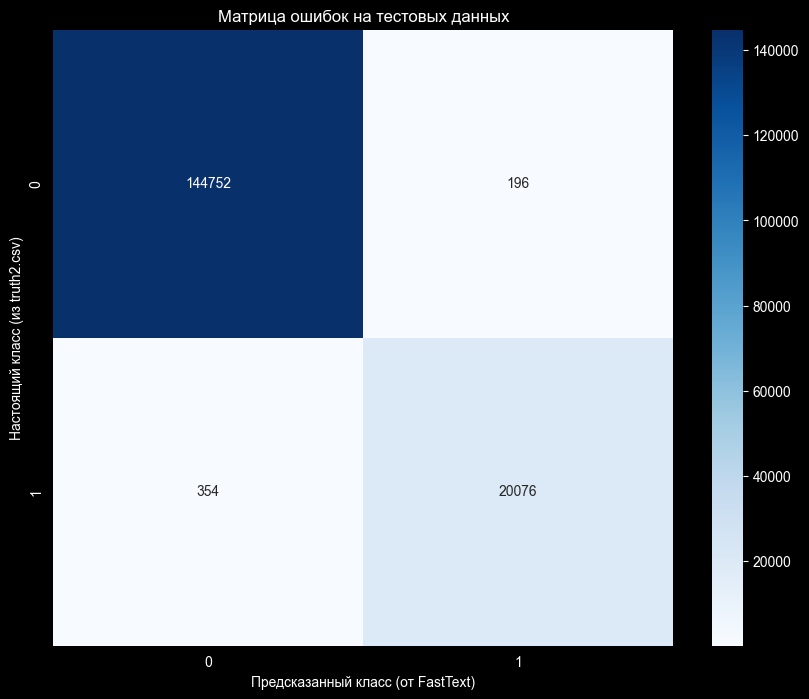

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок на тестовых данных')
plt.ylabel('Настоящий класс (из truth2.csv)')
plt.xlabel('Предсказанный класс (от FastText)')
plt.show()

In [49]:
errors_df =test_df[test_df['ft_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

Всего совершено ошибок: 550 из 165378 примеров



,ID,url,title,true_label,tfidf_label,ft_label
840,136149,pressa.tv,Любвеобильная девушка и друг,0,1,1
968,136277,rykodelie-dlay-vsex.ru,Открытки вытынанки к новому году своими руками,1,0,0
1656,136965,wondersex.ru,Доминирующая женщина 47 лет ищет нижнего партн...,1,0,0
1766,137075,seksi-new.online,Она похожа на меня / She Looks Like Me (2013),1,0,0
2001,137310,wherewhore.com,Delaware | WhereWhore,0,0,1


In [52]:
for idx, row in errors_df.sample(10, random_state=42).iterrows():
    # На вашем скриншоте я видел, что текст состоит из title + url
    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['ft_label']}")
    print("="*60)

Text: "Наслаждаюсь порнографией и мастурбацией": Послушница после 8 лет в монастыре ушла сниматься в порно - Жизнь - Главред | glavred.info
True: 0
Predicted: 1
Text: Luffy and Hancock moments! ALL SCENES!!!! YouTube 360p | www.lm.ee
True: 0
Predicted: 1
Text: 60 | 3gpjizz.mobi
True: 1
Predicted: 0
Text: Gabbie (Cifted Big Naturals 2) (2019) 2160p » Торрент трекер HDReactor.club Зерк... | hdreactor.club
True: 0
Predicted: 1
Text: Стройная Freja с маленькой грудью (17 фото) | pressa.tv
True: 1
Predicted: 0
Text: Хрупкий воробушек: Женщина, которую любили больше всех | pic-words.ru
True: 1
Predicted: 0
Text: Сиськи » База РуНет - Информационно - развлекательный портал | basaru.net.ru
True: 1
Predicted: 0
Text: 153 | domahi.com
True: 1
Predicted: 0
Text: Joey Valentine скачать торрент на Lovetorrent.net | lovetorrent.net
True: 1
Predicted: 0
Text: UFBW-2101 Megumi Tamura 田村芽実 – May. » Blog Idols Original - X-IDOL Video Blog Gravure IDOL | blog.aidol.asia
True: 0
Predicted: 1


**ВЫВОД:**

В ходе работы была обучена модель FastText в режиме обучения с учителем (supervised). Главное преимущество данного метода — работа не только с целыми словами, но и с символьными n-граммами (подсловами), что дает устойчивость к опечаткам и позволяет обрабатывать слова, которых не было в обучающей выборке.

Метрики качества:
- F1-score: `0.9865`
- Accuracy: `0.9967`
- Кол-во ошибок: `550`

Анализ:

- Модель ошибочно классифицировала новостную статью сайта Glavred как «взрослый контент» (False Positive). Это произошло из-за высокой концентрации слов-маркеров. FastText, работая на уровне n-грамм, видит эти слова, но не учитывает общий новостной контекст статьи. Это ограничение «мешка слов» — модель не понимает, что текст описывает событие, а не предоставляет сам контент.

- Шум и спорная разметка данных (Data Quality):
    В нескольких примерах (например, с сайтами HDReactor или Blog Idols) модель предсказала класс 1 (NSFW), в то время как в истинной разметке стоял класс 0. Анализируя текст (заголовки про "Naturals", "Idol", "Gravure"), можно сделать вывод, что модель оказалась точнее разметки. В данных присутствует заметный шум, что искусственно занижает итоговые метрики модели.

- Проблема коротких текстов и отсутствие данных:
    Примеры с заголовками типа «60» или «153» модель относит к безопасному классу, даже если домен является сомнительным (3gpjizz.mobi). При отсутствии содержательного текста модели катастрофически не хватает n-грамм для принятия решения.

Итоговое мнение: FastText показал высокую скорость работы (`~8 сек`) и отличную способность находить закономерности в самих словах и их частях. Однако для отделения «новостей о контенте» от «самого контента» модели недостаточно семантического понимания, что является точкой роста для использования более тяжелых моделей (например, BERT).

## BERT (fine-tuning)

**BERT** - Bidirectional Encoder Representations from Transformers. В отличие от предыдущих методов, BERT учитывает порядок слов и их взаимосвязи. В отличие от тех же RNN transformers используют метод attention и принимают во внимание всё предложение целиком, а не слово за словом. Если быть точнее, то всё благодаря двунаправленности (Bidirectional), BERT на каждом слое видит одновременно и левый, и правый контекст слова. Это позволяет ему различать тонкие нюансы: например, понять, что новость на «Главреде» — это журналистика, а не порнография, просто по структуре предложений и контекстуальным связям слов.

Мы проведем Fine-tuning — дообучим предобученную на миллионах текстов модель именно под нашу специфику (классификация URL и заголовков).

In [7]:
from transformers import AutoTokenizer

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

### Препроцессинг

Для проекта выберем подвыборку из обучающего датасета, на всех 130к примерно строк BERT будет очень долго обучаться.

In [8]:
train_subset = train_df.sample(5000)

In [9]:
def tokenize_function(examples):
    # Склеиваем url и title, как делали раньше
    texts = [f"{t} {u}" for t, u in zip(examples["title"], examples["url"])]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

Создаем объекты Dataset из pandas

In [11]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_subset[['title', 'url', 'label']])
tokenized_train = train_ds.map(tokenize_function, batched=True)

tokenized_test = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/165378 [00:00<?, ? examples/s]

### Обучение

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Гиперпараметры
training_args = TrainingArguments(
    output_dir="./bert_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    evaluation_strategy="no", # можно включить, если есть валидация
    save_strategy="no",
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
)

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

In [ ]:
%%time

trainer.train()

### Предсказание

In [ ]:
import numpy as np

# Получаем предсказания
predictions = trainer.predict(tokenized_test)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

In [ ]:
test_df['bert_label'] = y_pred_bert

Собираем метрики с тестовой выборки

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(test_df['true_label'], y_pred_bert).ravel()

precision = precision_sc(tp = tp, fp=fp)
recall = recall_sc(tp=tp, fn=fn)
bert_metrics = {
    'Model': 'FastText (Autotune)', # или укажите свои параметры
    'Accuracy': round(accuracy_sc(tp=tp, tn=tn, fp=fp, fn=fn), 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1-score': round(f1_sc(precision = precision, recall = recall), 4)
}

results_table = pd.DataFrame([bert_metrics])
# Выводим красивую итоговую таблицу
display(results_table)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['true_label'], y_pred_bert)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Матрица ошибок на тестовых данных - BERT')
plt.ylabel('Настоящий класс (из truth2.csv)')
plt.xlabel('Предсказанный класс (от FastText)')
plt.show()

In [ ]:
errors_df =test_df[test_df['bert_label'] != test_df['true_label']]
print(f"Всего совершено ошибок: {len(errors_df)} из {len(truth_df)} примеров\n")
errors_df.head()

In [ ]:
for idx, row in errors_df.sample(10, random_state=42).iterrows():
    # На вашем скриншоте я видел, что текст состоит из title + url
    text = f"{row.get('title', '')} | {row.get('url', '')}"

    print(f"Text: {text}")
    print(f"True: {row['true_label']}")
    print(f"Predicted: {row['bert_label']}")
    print("="*60)